# Retail Sales Machine Learning Project

## Objective
Build and evaluate multiple machine learning models to:
1. Predict weekly sales (Regression)
2. Classify high vs low sales weeks (Classification)

## Models Used
- Linear Regression
- Random Forest Regressor
- Logistic Regression
- Decision Tree Classifier


Imports & Configuration

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
    accuracy_score,
    classification_report,
    confusion_matrix
)

sns.set_style("whitegrid")
RANDOM_STATE = 42


Load Dataset

In [2]:
df = pd.read_csv("Walmart.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (6435, 8)


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


Basic Data Information

In [3]:
print("Columns:")
for col in df.columns:
    print(col)


Columns:
Store
Date
Weekly_Sales
Holiday_Flag
Temperature
Fuel_Price
CPI
Unemployment


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [6]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


Column Cleaning & Target Definition

In [8]:
# Clean column names
df.columns = df.columns.str.strip()

# Define target column explicitly
TARGET = "Weekly_Sales"

assert TARGET in df.columns, "Target column not found!"


Exploratory Data Analysis (EDA)

Distribution of Sales

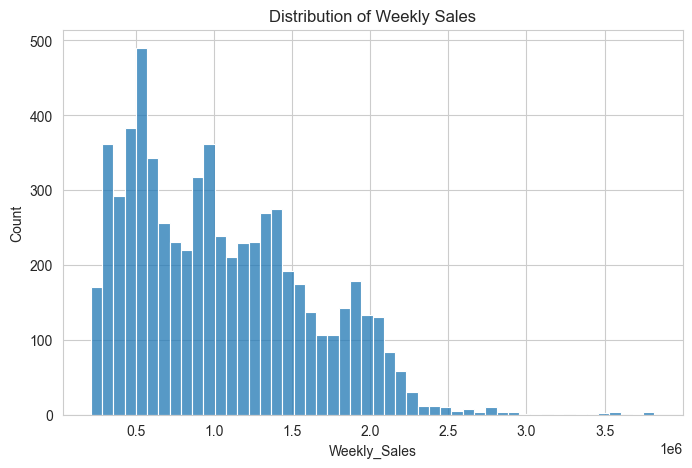

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df[TARGET], bins=50)
plt.title("Distribution of Weekly Sales")
plt.show()

Holiday Impact

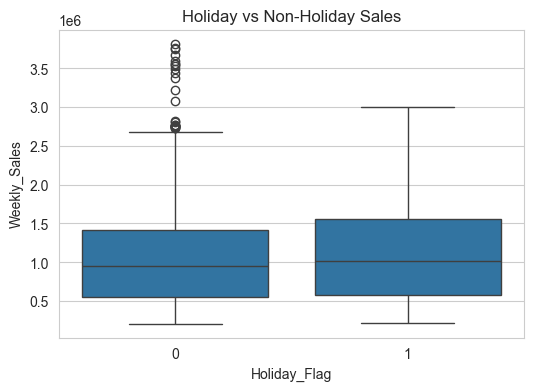

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x="Holiday_Flag", y=TARGET, data=df)
plt.title("Holiday vs Non-Holiday Sales")
plt.show()

Correlation Heatmap

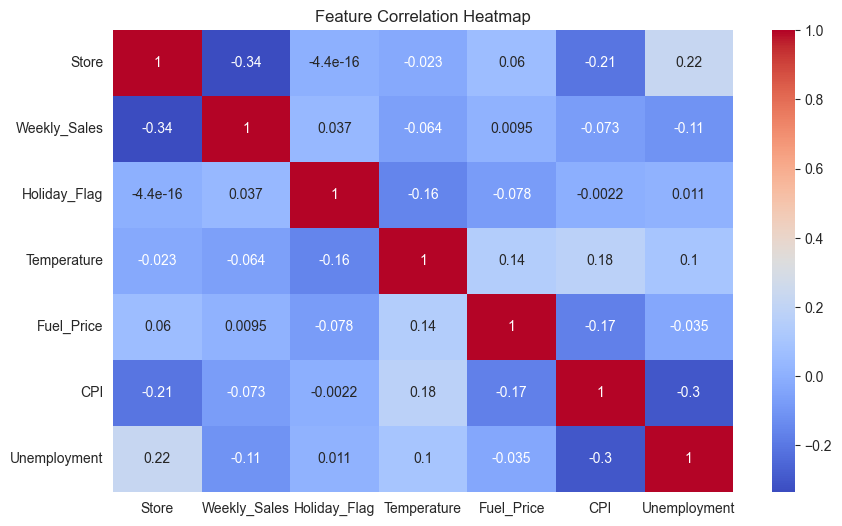

In [12]:
# Filter for numbers only
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

Feature Engineering & Preprocessing

In [13]:
# Use dayfirst=True or specify the exact format
df["Date"] = pd.to_datetime(df["Date"], format="%d-%m-%Y")



# Date features
df["Date"] = pd.to_datetime(df["Date"])
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Week"] = df["Date"].dt.isocalendar().week # .week is deprecated, use isocalendar().week


df.drop("Date", axis=1, inplace=True)

In [14]:
# Encode categorical features
le = LabelEncoder()
df["Store"] = le.fit_transform(df["Store"])


In [15]:
# Missing values check
df.isnull().sum()


Store           0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Year            0
Month           0
Week            0
dtype: int64

PART A: REGRESSION MODELS (Predict Exact Sales)

Train-Test Split (Regression)

In [16]:
X_reg = df.drop(TARGET, axis=1)
y_reg = df[TARGET]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=RANDOM_STATE
)


Linear Regression

In [18]:
lr = LinearRegression()
lr.fit(Xr_train, yr_train)

lr_preds = lr.predict(Xr_test)

print("Linear Regression Performance")
print("MAE:", mean_absolute_error(yr_test, lr_preds))
print("RMSE:", root_mean_squared_error(yr_test, lr_preds))
print("R2:", r2_score(yr_test, lr_preds))


Linear Regression Performance
MAE: 432594.97688780195
RMSE: 521583.50063959265
R2: 0.15553160499602847


Random Forest Regressor

In [19]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE
)

rf.fit(Xr_train, yr_train)
rf_preds = rf.predict(Xr_test)

print("Random Forest Performance")
print("MAE:", mean_absolute_error(yr_test, rf_preds))
print("RMSE:", root_mean_squared_error(yr_test, rf_preds))
print("R2:", r2_score(yr_test, rf_preds))


Random Forest Performance
MAE: 62022.51483061383
RMSE: 114106.3394247433
R2: 0.9595838205436641


Feature Importance

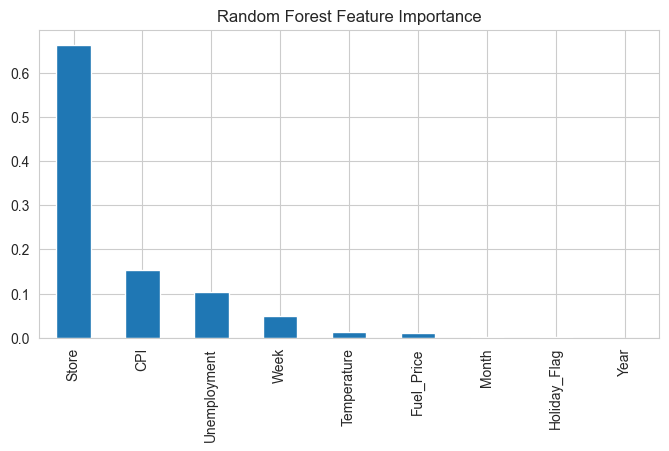

In [ ]:
pd.Series(rf.feature_importances_, index=X_reg.columns)\
  .sort_values(ascending=False)\
  .plot(kind="bar", figsize=(8,4))

plt.title("Random Forest Feature Importance")  #if model is trained without store, then Holiday_Flag becomes more important.
plt.show()


PART B: CLASSIFICATION MODELS (High vs Low Sales)

Creation of Classification Target

In [21]:
threshold = df[TARGET].median()
df["High_Sales"] = (df[TARGET] > threshold).astype(int)

df["High_Sales"].value_counts()


High_Sales
0    3218
1    3217
Name: count, dtype: int64

Train-Test Split (Classification)

In [22]:
X_clf = df.drop([TARGET, "High_Sales"], axis=1)
y_clf = df["High_Sales"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf,
    y_clf,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_clf
)


Logistic Regression

In [23]:
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(Xc_train, yc_train)

log_preds = log_reg.predict(Xc_test)

print("Logistic Regression Performance")
print("Accuracy:", accuracy_score(yc_test, log_preds))
print(classification_report(yc_test, log_preds))


Logistic Regression Performance
Accuracy: 0.6293706293706294
              precision    recall  f1-score   support

           0       0.64      0.58      0.61       644
           1       0.62      0.68      0.65       643

    accuracy                           0.63      1287
   macro avg       0.63      0.63      0.63      1287
weighted avg       0.63      0.63      0.63      1287



Decision Tree Classifier

In [24]:
dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=RANDOM_STATE
)

dt.fit(Xc_train, yc_train)
dt_preds = dt.predict(Xc_test)

print("Decision Tree Performance")
print("Accuracy:", accuracy_score(yc_test, dt_preds))
print(classification_report(yc_test, dt_preds))


Decision Tree Performance
Accuracy: 0.8624708624708625
              precision    recall  f1-score   support

           0       0.82      0.93      0.87       644
           1       0.91      0.80      0.85       643

    accuracy                           0.86      1287
   macro avg       0.87      0.86      0.86      1287
weighted avg       0.87      0.86      0.86      1287



Confusion Matrix

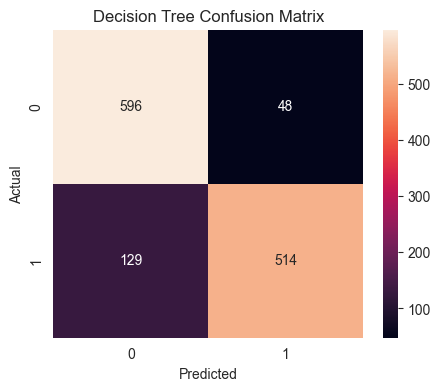

In [25]:
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(yc_test, dt_preds),
            annot=True, fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


## Final Summary

### Regression
- Random Forest outperformed Linear Regression
- Store, CPI, Unemployment and time-based features were important

### Classification
- Logistic Regression provided a strong baseline
- Decision Tree captured non-linear patterns better

### Business Insight
- High vs Low sales classification helps with promotions,
  staffing, and inventory planning
